# Model v3: NFL Draft AV Prediction with College Football Features

Extends model_v2 by joining college football career stats from `data/clean_cfb/05_04_all_players_2004_2024.csv`.

**Three models:** Regression Splines, XGBoost, TabNet  
**Walk-forward backtesting** (train on years < test_year)  
**Dedicated join analysis section** to evaluate match quality under different strategies

## 0. Imports & Config

In [13]:
import os, sys, glob
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.model_v3.tabnet import TabNetRegressor
from src.model_v3.data_loader import (
    load_cfb, load_draft, load_av_from_year_files, build_two_year_labels,
    join_cfb_to_draft, compare_join_strategies,
    NUM_COLS, CAT_COLS, CFB_STAT_COLS, DRAFT_NUM_COLS, DRAFT_CAT_COLS,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: cpu  |  PyTorch: 2.7.0


In [14]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DRAFT_CSV = os.path.join(REPO_ROOT, 'src', 'data', 'raw', 'draft_picks.csv')
CFB_CSV   = os.path.join(REPO_ROOT, 'data', 'clean_cfb', '05_04_all_players_2004_2024.csv')
AV_DIR    = os.path.join(REPO_ROOT, 'scraping_av', 'data')
OUT_DIR   = os.path.join(REPO_ROOT, 'poc_outputs_v3')
os.makedirs(OUT_DIR, exist_ok=True)

# ── Join toggles ──────────────────────────────────────────────────────────────
# Change these to experiment with different join strategies.
JOIN_ON_COLLEGE = False   # also require college name to match (drops more rows)
USE_FUZZY       = False   # use fuzzy name matching (recovers more rows, slower)
FUZZY_THRESHOLD = 85      # minimum score for fuzzy match (0–100)

WALK_FORWARD_START_YEAR = 2005  # first year with CFB data

# ── TabNet hyperparameters ────────────────────────────────────────────────────
TABNET_CFG = dict(
    n_d=16, n_a=16, n_steps=4, gamma=1.5,
    n_shared=2, n_step_dep=2, vbs=64, momentum=0.02, lambda_sparse=1e-3,
)
TRAIN_CFG = dict(
    lr=0.02, lr_decay=0.95, lr_decay_steps=200,
    batch_size=256, max_epochs=500, patience=50, val_fraction=0.2,
)

print('Config loaded.')
print(f'  JOIN_ON_COLLEGE={JOIN_ON_COLLEGE}  USE_FUZZY={USE_FUZZY}  FUZZY_THRESHOLD={FUZZY_THRESHOLD}')

Config loaded.
  JOIN_ON_COLLEGE=False  USE_FUZZY=False  FUZZY_THRESHOLD=85


## 1. Data Loading

In [15]:
draft   = load_draft(DRAFT_CSV)
cfb     = load_cfb(CFB_CSV)
av_long = load_av_from_year_files(AV_DIR)
labels  = build_two_year_labels(av_long)

print(f'Draft:  {len(draft):,} rows  seasons {draft.season.min()}–{draft.season.max()}')
print(f'CFB:    {len(cfb):,} rows  draft seasons {cfb.draft_season.min()}–{cfb.draft_season.max()}')
print(f'AV:     {len(av_long):,} season-player rows')
print(f'Labels: {len(labels):,} player-season labels')

Draft:  12,670 rows  seasons 1980–2025
CFB:    6,304 rows  draft seasons 2005–2025
AV:     53,245 season-player rows
Labels: 39,345 player-season labels


## 2. CFB Data — Join Analysis

This section evaluates how well different join strategies match college football data to draft picks.

**Join key:** `cfb.last_year + 1 == draft.season` (a player's last college year + 1 = expected draft year) and player name.

**Four strategies compared:**
- **A:** Exact name + season  
- **B:** Exact name + season + college  
- **C:** Fuzzy name + season  
- **D:** Fuzzy name + season + college

In [16]:
# ── 2.1 Strategy comparison table ─────────────────────────────────────────────
strategy_df = compare_join_strategies(draft, cfb, fuzzy_threshold=FUZZY_THRESHOLD)
print('Join strategy comparison:')
print(strategy_df.to_string(index=False))

Join strategy comparison:
          strategy  total_picks  picks_in_window  matched  matched_in_window match_rate_overall match_rate_in_window
          A: exact        12670             5407     2654               2654              20.9%                49.1%
B: exact + college        12670             5366     1957               1957              15.4%                36.5%
          C: fuzzy        12670             5366     2730               2730              21.5%                50.9%
D: fuzzy + college        12670             5366     1945               1945              15.4%                36.2%


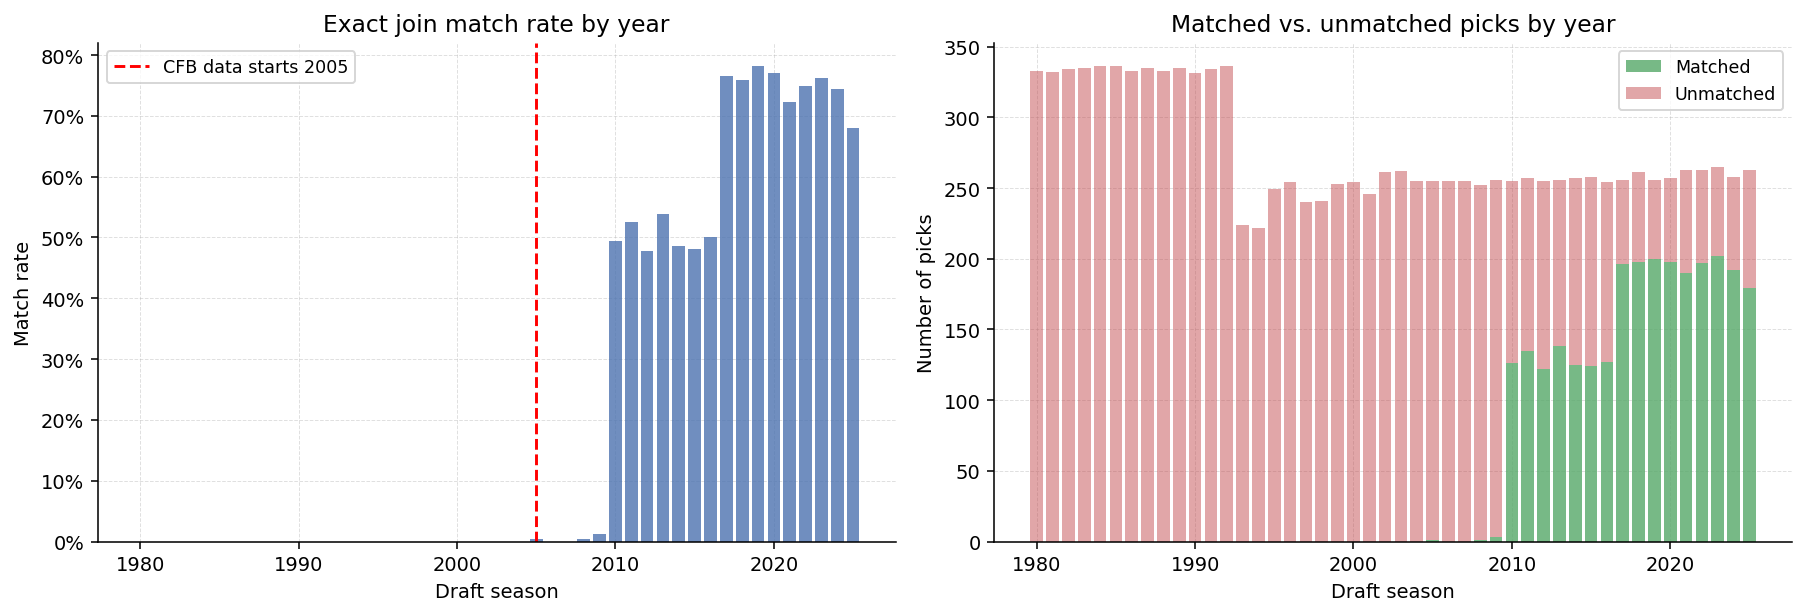


Overall: 2654 matched / 12670 total (20.9%)
In CFB window (2005, 2025): 2654 / 5407 (49.1%)


In [17]:
# ── 2.2 Match rate by draft year (exact join, no college filter) ───────────────
# We do the exact join and compute per-year match rates.
from src.model_v3.data_loader import CFB_STAT_COLS as _ALL_STAT_COLS

merged_exact, stats_exact = join_cfb_to_draft(
    draft, cfb, join_on_college=False, use_fuzzy=False)

stat_indicator = _ALL_STAT_COLS[0]  # use first stat col as match indicator
merged_exact['_matched'] = merged_exact[stat_indicator].notna()

by_year = (merged_exact.groupby('season')['_matched']
           .agg(total='count', matched='sum')
           .assign(match_rate=lambda x: x['matched'] / x['total']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=140)

ax = axes[0]
ax.bar(by_year.index, by_year['match_rate'], color='#4C72B0', alpha=0.8)
ax.axvline(cfb['draft_season'].min(), color='red', lw=1.5, ls='--', label=f'CFB data starts {cfb["draft_season"].min()}')
ax.set_xlabel('Draft season'); ax.set_ylabel('Match rate')
ax.set_title('Exact join match rate by year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

ax = axes[1]
ax.bar(by_year.index, by_year['matched'], color='#55A868', alpha=0.8, label='Matched')
ax.bar(by_year.index, by_year['total'] - by_year['matched'],
       bottom=by_year['matched'], color='#C44E52', alpha=0.5, label='Unmatched')
ax.set_xlabel('Draft season'); ax.set_ylabel('Number of picks')
ax.set_title('Matched vs. unmatched picks by year')
ax.legend(fontsize=9)
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_join_match_by_year.png'), dpi=180)
plt.show()
print(f"\nOverall: {stats_exact['matched_total']} matched / {stats_exact['total_picks']} total "
      f"({stats_exact['match_rate_overall']:.1%})")
print(f"In CFB window {stats_exact['cfb_window']}: "
      f"{stats_exact['matched_in_window']} / {stats_exact['picks_in_window']} "
      f"({stats_exact['match_rate_in_window']:.1%})")

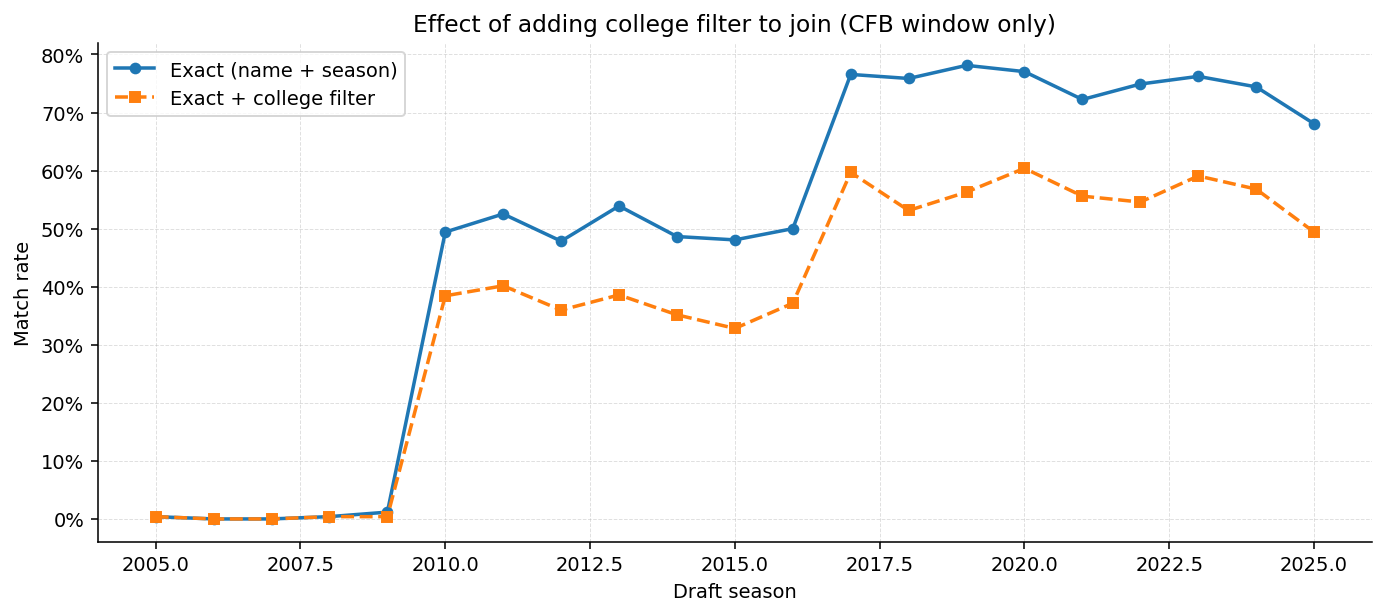

College filter drops 697 matches in window (26.3% of exact matches)


In [18]:
# ── 2.3 Impact of college filter ──────────────────────────────────────────────
merged_college, stats_college = join_cfb_to_draft(
    draft, cfb, join_on_college=True, use_fuzzy=False)
merged_college['_matched'] = merged_college[stat_indicator].notna()

by_year_col = (merged_college.groupby('season')['_matched']
               .agg(total='count', matched='sum')
               .assign(match_rate=lambda x: x['matched'] / x['total']))

# Window comparison
win = cfb['draft_season'].min()
in_win = by_year[by_year.index >= win]
in_win_col = by_year_col[by_year_col.index >= win]

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=140)
ax.plot(in_win.index, in_win['match_rate'], marker='o', lw=1.8, ms=5, label='Exact (name + season)')
ax.plot(in_win_col.index, in_win_col['match_rate'], marker='s', lw=1.8, ms=5,
        linestyle='--', label='Exact + college filter')
ax.set_xlabel('Draft season'); ax.set_ylabel('Match rate')
ax.set_title('Effect of adding college filter to join (CFB window only)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=10)
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_join_college_impact.png'), dpi=180)
plt.show()

dropped = stats_exact['matched_in_window'] - stats_college['matched_in_window']
print(f"College filter drops {dropped} matches in window "
      f"({dropped / stats_exact['matched_in_window']:.1%} of exact matches)")

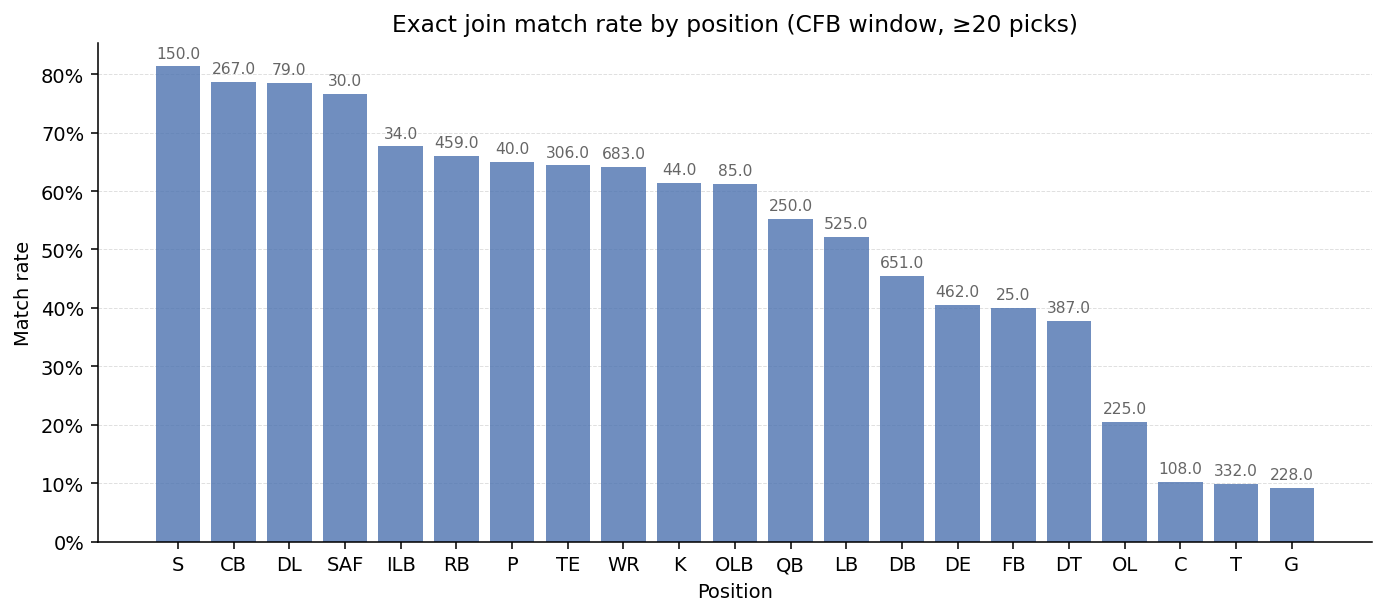

In [19]:
# ── 2.4 Match rate by position (exact join, CFB window) ───────────────────────
in_window_mask = merged_exact['season'].between(
    cfb['draft_season'].min(), cfb['draft_season'].max())
df_win = merged_exact[in_window_mask].copy()

if 'position' in df_win.columns:
    by_pos = (df_win.groupby('position')['_matched']
              .agg(total='count', matched='sum')
              .assign(match_rate=lambda x: x['matched'] / x['total'])
              .sort_values('match_rate', ascending=False))
    # Filter to positions with at least 20 picks
    by_pos = by_pos[by_pos['total'] >= 20]

    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=140)
    bars = ax.bar(by_pos.index, by_pos['match_rate'], color='#4C72B0', alpha=0.8)
    ax.set_xlabel('Position'); ax.set_ylabel('Match rate')
    ax.set_title('Exact join match rate by position (CFB window, ≥20 picks)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar, (_, row) in zip(bars, by_pos.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{row['total']}", ha='center', va='bottom', fontsize=8, color='0.4')
    ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'plot_join_match_by_position.png'), dpi=180)
    plt.show()

In [20]:
# ── 2.5 Sample matched and unmatched picks ────────────────────────────────────
in_window_mask2 = merged_exact['season'] >= cfb['draft_season'].min()
matched_sample   = merged_exact[in_window_mask2 & merged_exact['_matched']]
unmatched_sample = merged_exact[in_window_mask2 & ~merged_exact['_matched']]

show_cols = ['season', 'pfr_player_name', 'position', 'college', 'pick']
show_cols = [c for c in show_cols if c in merged_exact.columns]

print('=== 10 matched picks ===')
print(matched_sample[show_cols].head(10).to_string(index=False))
print()
print('=== 10 unmatched picks ===')
print(unmatched_sample[show_cols].head(10).to_string(index=False))

=== 10 matched picks ===
 season pfr_player_name position          college  pick
   2005   Justin Miller       DB          Clemson    57
   2008  Spencer Larsen       LB          Arizona   183
   2009  Jason Williams       LB Western Illinois    69
   2009   Robert Henson       LB              TCU   186
   2009      Brad Jones       LB         Colorado   218
   2010    Sam Bradford       QB         Oklahoma     1
   2010   Ndamukong Suh       DT         Nebraska     2
   2010      Eric Berry       DB        Tennessee     5
   2010       Joe Haden       DB          Florida     7
   2010 Rolando McClain       LB          Alabama     8

=== 10 unmatched picks ===
 season   pfr_player_name position        college  pick
   2005        Alex Smith       QB           Utah     1
   2005      Ronnie Brown       RB         Auburn     2
   2005   Braylon Edwards       WR       Michigan     3
   2005     Cedric Benson       RB          Texas     4
   2005 Cadillac Williams       RB         Auburn  

## 3. Build Modeling Dataset

Uses the join strategy configured at the top (`JOIN_ON_COLLEGE`, `USE_FUZZY`).  
Attaches AV labels and drops rows without a 2-year AV target.

In [21]:
merged, join_stats = join_cfb_to_draft(
    draft, cfb,
    join_on_college=JOIN_ON_COLLEGE,
    use_fuzzy=USE_FUZZY,
    fuzzy_threshold=FUZZY_THRESHOLD,
)

df = merged.rename(columns={'season': 'draft_season'}).merge(
    labels, on=['draft_season', 'pfr_player_id'], how='left'
)
df = df.dropna(subset=['av_2yr']).copy()
df['av_2yr'] = df['av_2yr'].astype(float)

cfb_matched_pct = df[CFB_STAT_COLS[0]].notna().mean()
print(f'Dataset: {len(df):,} rows  |  years {df.draft_season.min()}–{df.draft_season.max()}')
print(f'Target av_2yr: mean={df.av_2yr.mean():.2f}  std={df.av_2yr.std():.2f}  max={df.av_2yr.max():.0f}')
print(f'CFB features filled: {cfb_matched_pct:.1%} of rows')
print(f'Join stats: {join_stats}')
df.head()

Dataset: 4,739 rows  |  years 1999–2024
Target av_2yr: mean=6.35  std=5.61  max=41
CFB features filled: 42.1% of rows
Join stats: {'total_picks': 12670, 'cfb_window': (2005, 2025), 'picks_in_window': 5407, 'matched_total': 2654, 'matched_in_window': 2654, 'match_rate_overall': 0.20879553142947055, 'match_rate_in_window': 0.49084520066580356, 'join_on_college': False, 'use_fuzzy': False}


,draft_season,pick,round,team,position,category,side,age,college,pfr_player_id,...,punting_no,punting_yds,punting_ypp,kickreturns_no,kickreturns_yds,kickreturns_avg,puntreturns_no,puntreturns_yds,puntreturns_avg,av_2yr
5773,1999,1,1,CLE,QB,QB,O,22.0,Kentucky,CoucTi00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5774,1999,2,1,PHI,QB,QB,O,22.0,Syracuse,McNaDo00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0
5775,1999,3,1,CIN,QB,QB,O,24.0,Oregon,SmitAk00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
5776,1999,4,1,IND,RB,RB,O,21.0,Miami (FL),JameEd00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.0
5777,1999,5,1,NOR,RB,RB,O,22.0,Texas,WillRi00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0


## 4. Preprocessing Helpers

In [22]:
def build_spline_preprocessor(df_train):
    """SplineTransformer on pick, median imputation on all other numerics, OHE on cats."""
    num_cols = [c for c in NUM_COLS if c in df_train.columns]
    cat_cols = [c for c in CAT_COLS if c in df_train.columns]
    transformers = []
    if 'pick' in num_cols:
        transformers.append(('pick_spline', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('spl', SplineTransformer(n_knots=6, degree=3, include_bias=False)),
        ]), ['pick']))
        rest = [c for c in num_cols if c != 'pick']
        if rest:
            transformers.append(('num', SimpleImputer(strategy='median'), rest))
    elif num_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))
    return ColumnTransformer(transformers, remainder='drop'), num_cols, cat_cols


def build_tree_preprocessor(df_train):
    """Median imputation on numerics, OHE on cats (no spline needed for trees)."""
    num_cols = [c for c in NUM_COLS if c in df_train.columns]
    cat_cols = [c for c in CAT_COLS if c in df_train.columns]
    transformers = []
    if num_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), num_cols))
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))
    return ColumnTransformer(transformers, remainder='drop'), num_cols, cat_cols


def get_feature_names(pre, num_cols, cat_cols):
    names = list(num_cols)
    if cat_cols and 'cat' in pre.named_transformers_:
        names += list(pre.named_transformers_['cat'].get_feature_names_out(cat_cols))
    return names


def to_tensor(arr):
    return torch.tensor(arr.astype(np.float32))


def eval_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    sp   = float(spearmanr(y_true, y_pred).correlation)
    return mae, rmse, sp


print('Preprocessing helpers defined.')

Preprocessing helpers defined.


## 5. TabNet Training Loop

In [23]:
def train_one_fold(X_tr, y_tr, n_features, verbose=True):
    model = TabNetRegressor(n_features=n_features, **TABNET_CFG).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_CFG['lr'])
    scheduler = ExponentialLR(optimizer, gamma=TRAIN_CFG['lr_decay'])

    n_val = max(1, int(len(X_tr) * TRAIN_CFG['val_fraction']))
    Xt, Xv = X_tr[:-n_val], X_tr[-n_val:]
    yt, yv = y_tr[:-n_val], y_tr[-n_val:]

    loader = DataLoader(TensorDataset(to_tensor(Xt), to_tensor(yt)),
                        batch_size=TRAIN_CFG['batch_size'], shuffle=True, drop_last=True)
    Xv_t, yv_t = to_tensor(Xv).to(DEVICE), to_tensor(yv).to(DEVICE)

    best_val, best_state, patience_ctr = float('inf'), None, 0
    train_hist, val_hist = [], []
    step = 0

    for epoch in range(TRAIN_CFG['max_epochs']):
        model.train()
        ep_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred, sp, _ = model(Xb)
            loss = model.loss(pred, yb, sp)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
            step += 1
            if step % TRAIN_CFG['lr_decay_steps'] == 0:
                scheduler.step()
        train_hist.append(ep_loss / max(1, len(loader)))

        model.eval()
        with torch.no_grad():
            vp, vsp, _ = model(Xv_t)
            vl = model.loss(vp, yv_t, vsp).item()
        val_hist.append(vl)

        if vl < best_val:
            best_val, patience_ctr = vl, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if verbose and (epoch + 1) % 100 == 0:
            print(f'  epoch {epoch+1:4d}  train={train_hist[-1]:.3f}  val={vl:.3f}  '
                  f'best={best_val:.3f}  patience={patience_ctr}/{TRAIN_CFG["patience"]}')

        if patience_ctr >= TRAIN_CFG['patience']:
            if verbose: print(f'  Early stop at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    return model, train_hist, val_hist

print('Training loop defined.')

Training loop defined.


## 6. Walk-forward Evaluation — All Three Models

In [24]:
feat_cols = [c for c in (NUM_COLS + CAT_COLS) if c in df.columns]
X_raw = df[feat_cols].copy()
y     = df['av_2yr'].values
years = df['draft_season'].values

unique_years = sorted(np.unique(years))
test_years   = [yr for yr in unique_years if yr > WALK_FORWARD_START_YEAR]
print(f'Test years: {test_years[:5]} ... {test_years[-3:]}')
print(f'Total folds: {len(test_years)}')

results = []
last = {}   # stores final-fold artifacts for visualization
latest_year = max(test_years)

for test_year in test_years:
    tr_mask = (years >= WALK_FORWARD_START_YEAR) & (years < test_year)
    te_mask = years == test_year
    X_tr_raw, X_te_raw = X_raw[tr_mask], X_raw[te_mask]
    y_tr, y_te = y[tr_mask], y[te_mask]

    print(f'\n=== Test {test_year}  train={tr_mask.sum()}  test={te_mask.sum()} ===')

    # ── Spline Ridge ──────────────────────────────────────────────────────────
    pre_s, _, _ = build_spline_preprocessor(X_tr_raw)
    spline_pipe = Pipeline([('pre', pre_s), ('reg', Ridge(alpha=1.0))])
    spline_pipe.fit(X_tr_raw, y_tr)
    pred_s = spline_pipe.predict(X_te_raw)
    mae_s, rmse_s, sp_s = eval_metrics(y_te, pred_s)
    print(f'  Spline  MAE={mae_s:.3f}  RMSE={rmse_s:.3f}  Spearman={sp_s:.3f}')

    # ── XGBoost ───────────────────────────────────────────────────────────────
    pre_x, _num_x, _cat_x = build_tree_preprocessor(X_tr_raw)
    xgb_pipe = Pipeline([
        ('pre', pre_x),
        ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                              subsample=0.8, colsample_bytree=0.8,
                              reg_lambda=1.0, random_state=42)),
    ])
    xgb_pipe.fit(X_tr_raw, y_tr)
    pred_x = xgb_pipe.predict(X_te_raw)
    mae_x, rmse_x, sp_x = eval_metrics(y_te, pred_x)
    print(f'  XGBoost MAE={mae_x:.3f}  RMSE={rmse_x:.3f}  Spearman={sp_x:.3f}')

    # ── TabNet ────────────────────────────────────────────────────────────────
    pre_t, _num_t, _cat_t = build_tree_preprocessor(X_tr_raw)
    X_tr_t = pre_t.fit_transform(X_tr_raw).astype(np.float32)
    X_te_t = pre_t.transform(X_te_raw).astype(np.float32)
    feat_names_t = get_feature_names(pre_t, _num_t, _cat_t)

    tabnet, th, vh = train_one_fold(X_tr_t, y_tr, X_tr_t.shape[1], verbose=True)
    tabnet.eval()
    with torch.no_grad():
        Xte_ten = to_tensor(X_te_t).to(DEVICE)
        pred_raw, _, masks = tabnet(Xte_ten)
        pred_t = pred_raw.cpu().numpy()
        importance = tabnet.encoder.aggregate_importance(masks).cpu().numpy()
    mae_t, rmse_t, sp_t = eval_metrics(y_te, pred_t)
    print(f'  TabNet  MAE={mae_t:.3f}  RMSE={rmse_t:.3f}  Spearman={sp_t:.3f}')

    results.append({
        'test_year': int(test_year), 'n_test': int(te_mask.sum()),
        'spline_mae': mae_s, 'spline_rmse': rmse_s, 'spline_spearman': sp_s,
        'xgb_mae': mae_x,   'xgb_rmse': rmse_x,   'xgb_spearman': sp_x,
        'tabnet_mae': mae_t, 'tabnet_rmse': rmse_t, 'tabnet_spearman': sp_t,
    })

    if test_year == latest_year:
        last = dict(
            y_te=y_te, pred_s=pred_s, pred_x=pred_x, pred_t=pred_t,
            importance=importance, feat_names=feat_names_t,
            xgb_pipe=xgb_pipe, num_x=_num_x, cat_x=_cat_x,
            train_hist=th, val_hist=vh,
        )

res_df = pd.DataFrame(results)
print('\n=== Walk-forward summary ===')
print(res_df.to_string(index=False))
res_df.to_csv(os.path.join(OUT_DIR, 'walkforward_results_v3.csv'), index=False)

Test years: [2006, 2007, 2008, 2009, 2010] ... [2022, 2023, 2024]
Total folds: 19

=== Test 2006  train=161  test=172 ===
  Spline  MAE=4.148  RMSE=5.551  Spearman=0.425


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.

  XGBoost MAE=4.055  RMSE=5.374  Spearman=0.467
  Early stop at epoch 51
  TabNet  MAE=7.213  RMSE=9.282  Spearman=0.105

=== Test 2007  train=333  test=172 ===
  Spline  MAE=4.081  RMSE=5.259  Spearman=0.409


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  XGBoost MAE=3.949  RMSE=5.089  Spearman=0.389
  Early stop at epoch 69
  TabNet  MAE=4.247  RMSE=5.712  Spearman=-0.006

=== Test 2008  train=505  test=169 ===
  Spline  MAE=4.045  RMSE=5.305  Spearman=0.482


...

  XGBoost MAE=3.733  RMSE=4.838  Spearman=0.456
  epoch  100  train=20.666  val=21.327  best=19.950  patience=41/50
  Early stop at epoch 109
  TabNet  MAE=3.468  RMSE=4.609  Spearman=0.497

=== Test 2010  train=848  test=173 ===
  Spline  MAE=216.648  RMSE=1130.705  Spearman=0.305


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['receiving_ypr' 'kicking_pct' 'punting_ypp' 'kickreturns_avg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.

  XGBoost MAE=3.653  RMSE=4.816  Spearman=0.520
  epoch  100  train=23.509  val=22.195  best=20.884  patience=29/50
  Early stop at epoch 121
  TabNet  MAE=3.410  RMSE=4.518  Spearman=0.534

=== Test 2011  train=1021  test=188 ===
  Spline  MAE=4.214  RMSE=6.157  Spearman=0.552


/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['kicking_pct']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['kicking_pct']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['kicking_pct']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/arnav/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['kicking_pct']. At least one non-miss

  XGBoost MAE=3.901  RMSE=5.583  Spearman=0.548
  epoch  100  train=21.169  val=19.697  best=18.465  patience=23/50
  Early stop at epoch 127
  TabNet  MAE=3.968  RMSE=5.598  Spearman=0.596

=== Test 2012  train=1209  test=184 ===
  Spline  MAE=3.631  RMSE=5.302  Spearman=0.560
  XGBoost MAE=3.415  RMSE=4.724  Spearman=0.590
  Early stop at epoch 67
  TabNet  MAE=3.678  RMSE=5.034  Spearman=0.605

=== Test 2013  train=1393  test=174 ===
  Spline  MAE=4.046  RMSE=5.377  Spearman=0.407
  XGBoost MAE=3.691  RMSE=4.894  Spearman=0.483
  epoch  100  train=23.338  val=22.902  best=21.795  patience=30/50
  Early stop at epoch 120
  TabNet  MAE=3.618  RMSE=4.888  Spearman=0.458

=== Test 2014  train=1567  test=169 ===
  Spline  MAE=3.994  RMSE=5.194  Spearman=0.443
  XGBoost MAE=3.775  RMSE=4.909  Spearman=0.500
  Early stop at epoch 81
  TabNet  MAE=3.912  RMSE=5.145  Spearman=0.471

=== Test 2015  train=1736  test=175 ===
  Spline  MAE=3.274  RMSE=4.294  Spearman=0.645
  XGBoost MAE=3.144  R

## 7. Loss Curves (final fold)

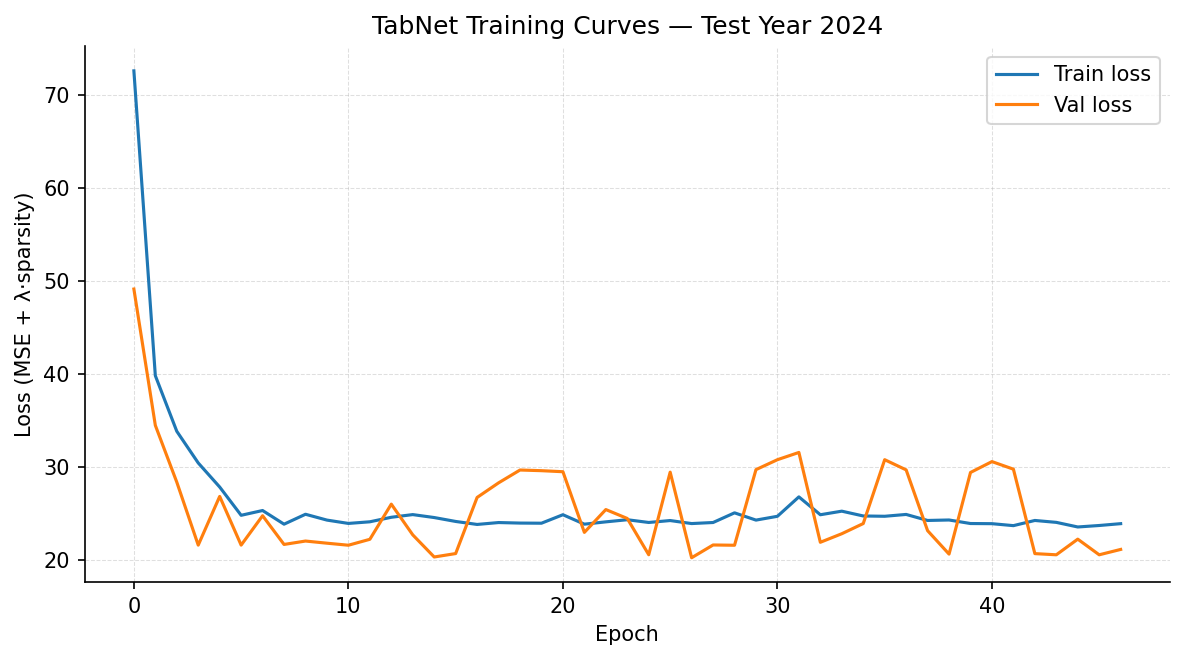

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.plot(last['train_hist'], label='Train loss', lw=1.5)
ax.plot(last['val_hist'],   label='Val loss',   lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE + λ·sparsity)')
ax.set_title(f'TabNet Training Curves — Test Year {latest_year}')
ax.legend()
ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'plot_tabnet_loss_curves_{latest_year}.png'), dpi=180)
plt.show()

## 8. Predicted vs. Actual (final fold)

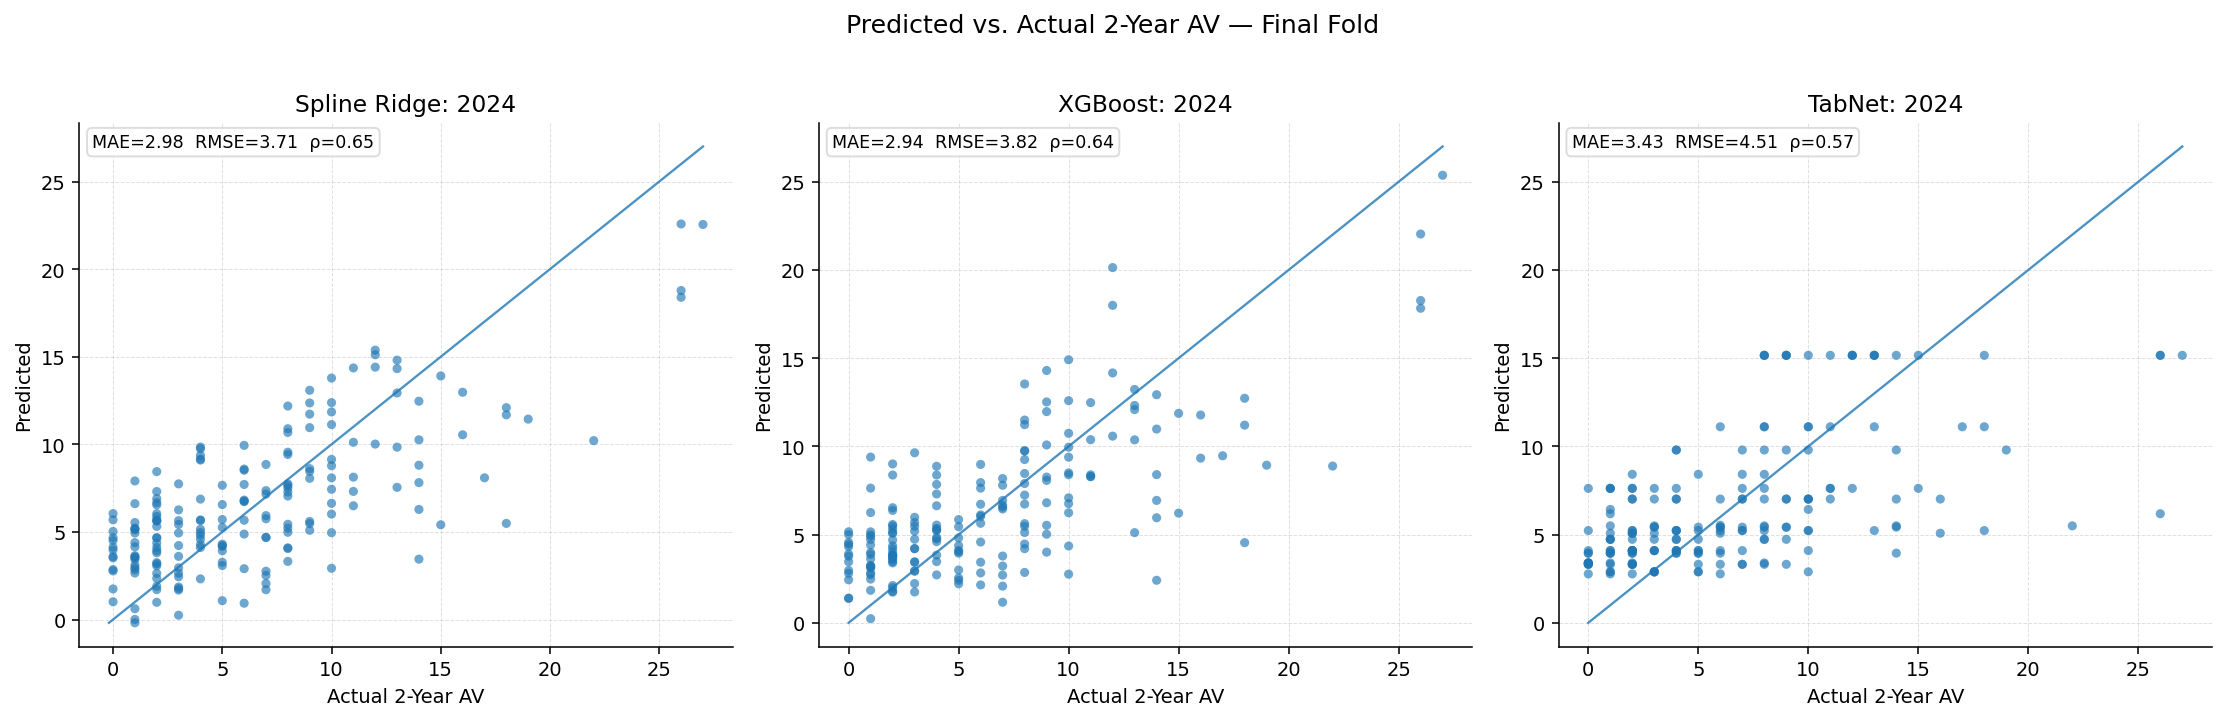

In [26]:
def plot_pred_vs_actual(y_true, y_pred, title, ax=None):
    mae, rmse, sp = eval_metrics(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5), dpi=140)
    ax.scatter(y_true, y_pred, s=22, alpha=0.65, edgecolor='none')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], lw=1.2, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f'Actual 2-Year AV'); ax.set_ylabel('Predicted')
    ax.text(0.02, 0.98, f'MAE={mae:.2f}  RMSE={rmse:.2f}  ρ={sp:.2f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.9, ec='0.85'))
    ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
    for s in ['top','right']: ax.spines[s].set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=140)
plot_pred_vs_actual(last['y_te'], last['pred_s'], f'Spline Ridge: {latest_year}', axes[0])
plot_pred_vs_actual(last['y_te'], last['pred_x'], f'XGBoost: {latest_year}',      axes[1])
plot_pred_vs_actual(last['y_te'], last['pred_t'], f'TabNet: {latest_year}',        axes[2])
fig.suptitle('Predicted vs. Actual 2-Year AV — Final Fold', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'plot_pred_vs_actual_{latest_year}.png'), dpi=180)
plt.show()

## 9. Feature Importance (final fold)

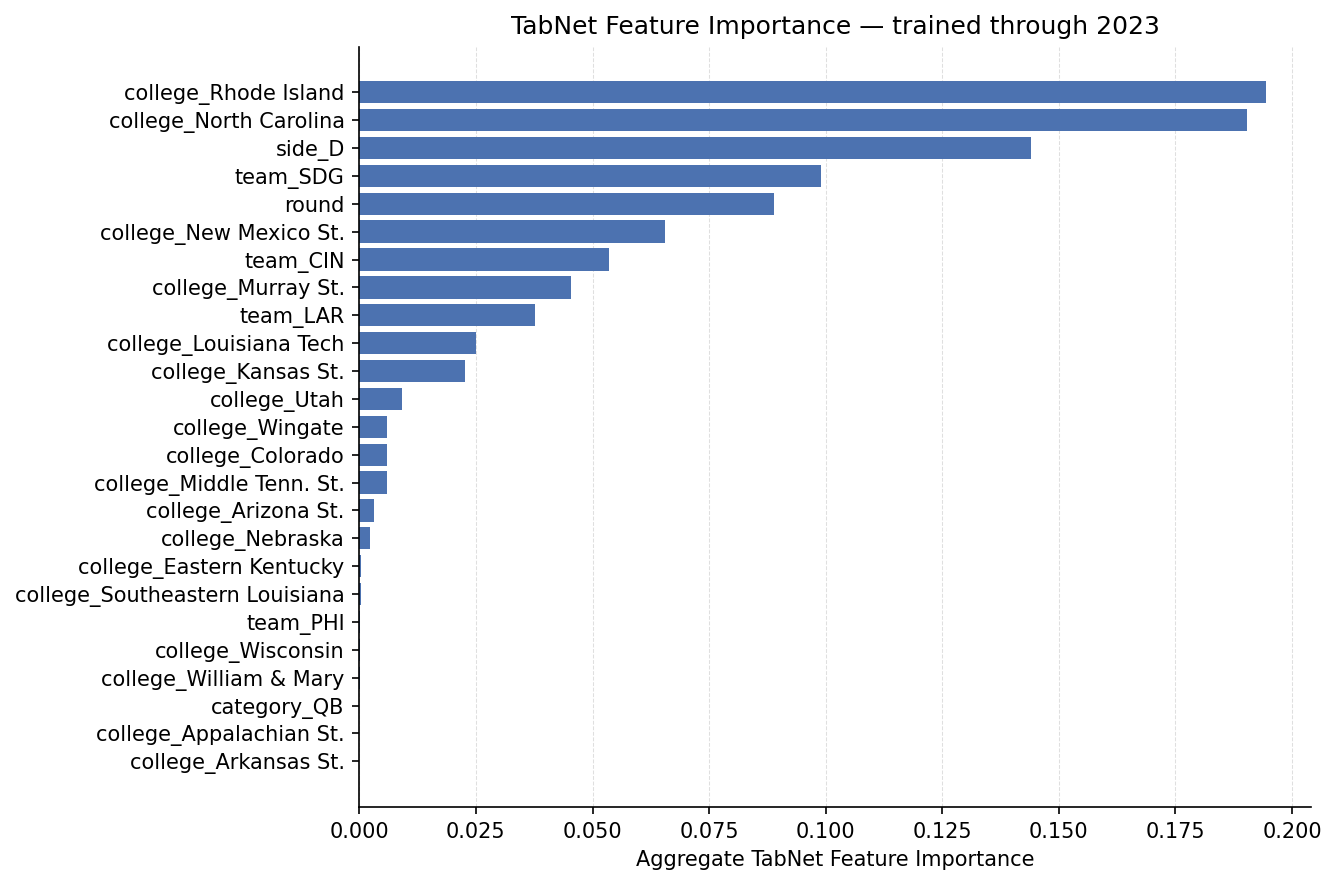

Top-10 features (TabNet):
   1. college_Rhode Island                     0.1943
   2. college_North Carolina                   0.1903
   3. side_D                                   0.1441
   4. team_SDG                                 0.0989
   5. round                                    0.0890
   6. college_New Mexico St.                   0.0656
   7. team_CIN                                 0.0536
   8. college_Murray St.                       0.0454
   9. team_LAR                                 0.0377
  10. college_Louisiana Tech                   0.0251


In [27]:
# TabNet aggregate attention importance
top_n = 25
idx = np.argsort(last['importance'])[::-1][:top_n]

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([last['feat_names'][i] for i in reversed(idx)],
         last['importance'][list(reversed(idx))], color='#4C72B0')
ax.set_xlabel('Aggregate TabNet Feature Importance')
ax.set_title(f'TabNet Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_tabnet_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (TabNet):')
for rank, i in enumerate(idx[:10], 1):
    print(f'  {rank:2d}. {last["feat_names"][i]:<40s} {last["importance"][i]:.4f}')

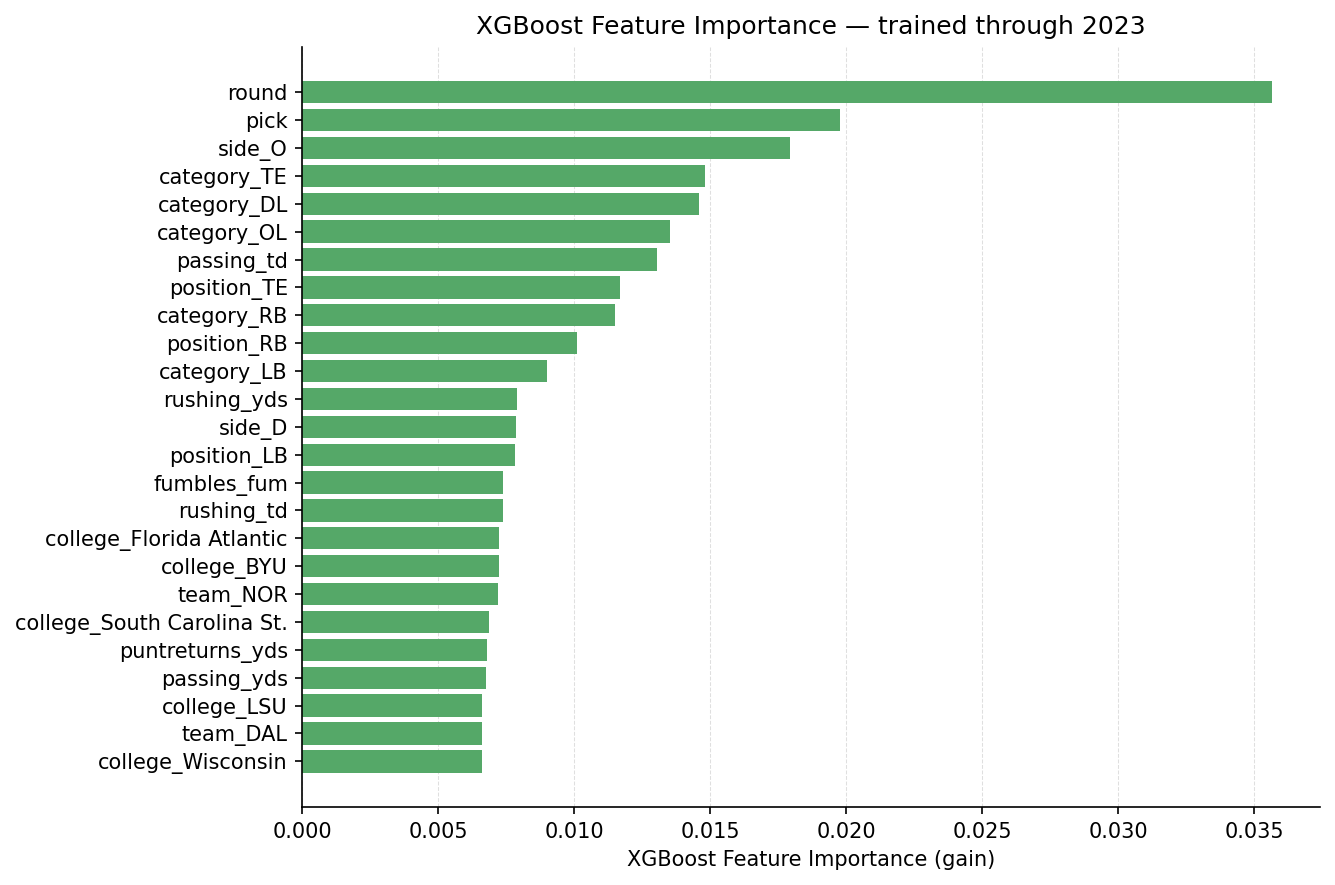

Top-10 features (XGBoost):
   1. round                                    0.0356
   2. pick                                     0.0198
   3. side_O                                   0.0179
   4. category_TE                              0.0148
   5. category_DL                              0.0146
   6. category_OL                              0.0135
   7. passing_td                               0.0130
   8. position_TE                              0.0117
   9. category_RB                              0.0115
  10. position_RB                              0.0101


In [28]:
# XGBoost feature importance
xgb_imp = last['xgb_pipe'].named_steps['xgb'].feature_importances_
xgb_names = get_feature_names(
    last['xgb_pipe'].named_steps['pre'], last['num_x'], last['cat_x'])

idx_x = np.argsort(xgb_imp)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
ax.barh([xgb_names[i] for i in reversed(idx_x)],
         xgb_imp[list(reversed(idx_x))], color='#55A868')
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title(f'XGBoost Feature Importance — trained through {latest_year-1}')
ax.grid(True, axis='x', ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_xgb_feature_importance.png'), dpi=180)
plt.show()

print('Top-10 features (XGBoost):')
for rank, i in enumerate(idx_x[:10], 1):
    print(f'  {rank:2d}. {xgb_names[i]:<40s} {xgb_imp[i]:.4f}')

## 10. Walk-forward Metrics Over Time

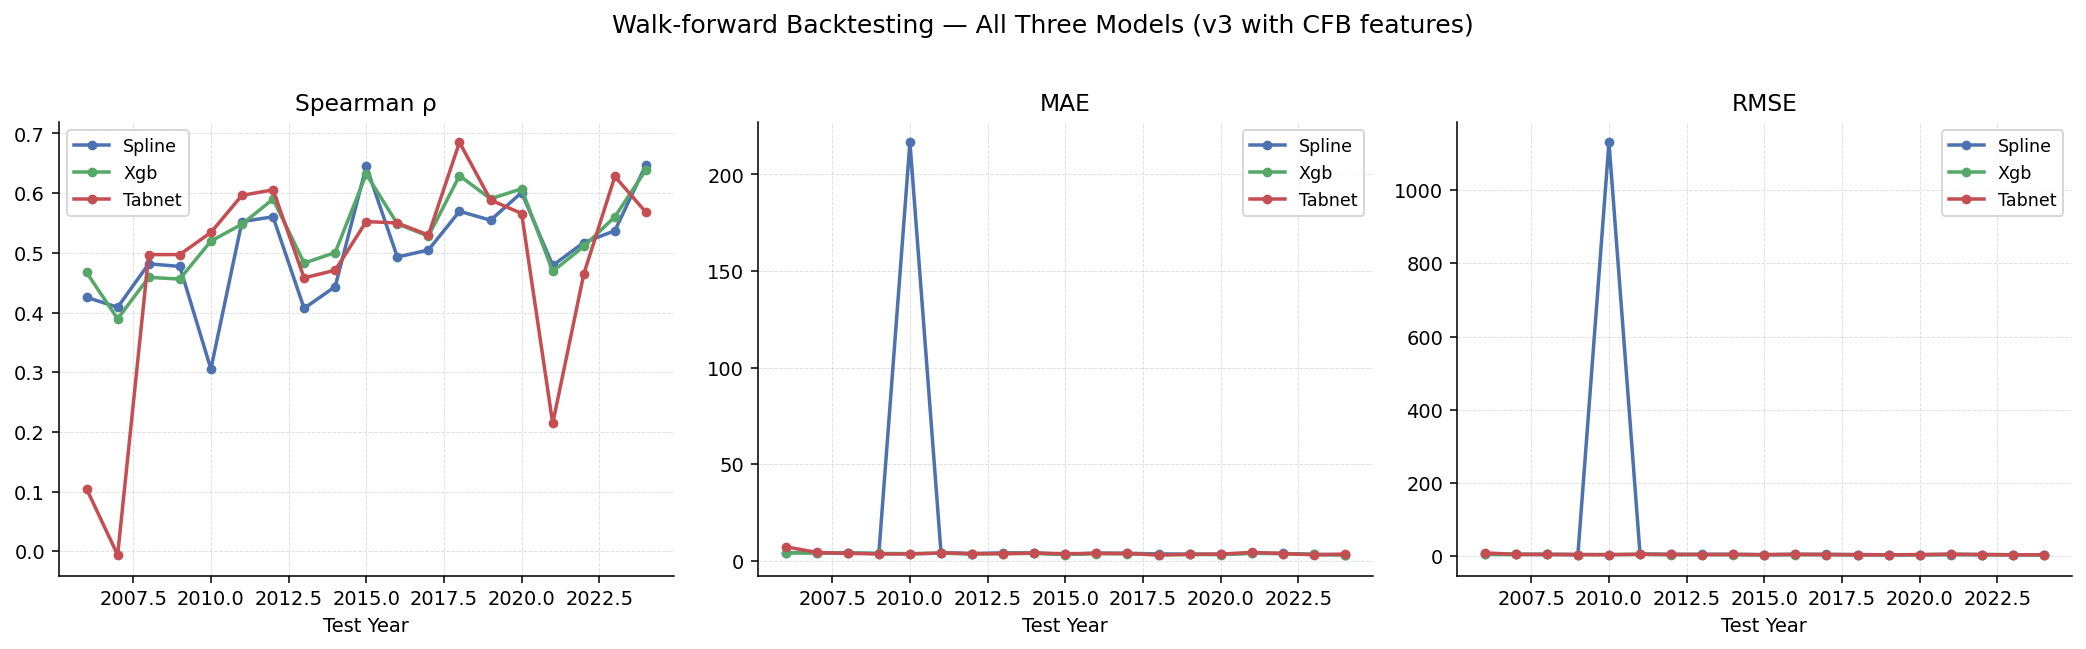

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=140)
metrics = [('spearman', 'Spearman ρ'), ('mae', 'MAE'), ('rmse', 'RMSE')]
colors  = {'spline': '#4C72B0', 'xgb': '#55A868', 'tabnet': '#C44E52'}

for ax, (metric, label) in zip(axes, metrics):
    for model, color in colors.items():
        col = f'{model}_{metric}'
        ax.plot(res_df['test_year'], res_df[col], marker='o', lw=1.8, ms=4,
                label=model.title(), color=color)
    ax.set_title(label); ax.set_xlabel('Test Year')
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
    for s in ['top','right']: ax.spines[s].set_visible(False)

fig.suptitle('Walk-forward Backtesting — All Three Models (v3 with CFB features)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'plot_walkforward_metrics_v3.png'), dpi=180)
plt.show()

## 11. TabNet Attention Mask Visualisation (final fold)

In [30]:
# Rerun the final model on the test set to get step-level masks
pre_final, _nf, _cf = build_tree_preprocessor(X_raw[years < latest_year])
Xte_final = pre_final.fit_transform(X_raw[years == latest_year]).astype(np.float32)
feat_final = get_feature_names(pre_final, _nf, _cf)

n_show = min(40, len(Xte_final))
# Note: this reuses the last trained tabnet model
tabnet.eval()
with torch.no_grad():
    _, _, step_masks = tabnet(to_tensor(Xte_final[:n_show]).to(DEVICE))

top_feat_idx   = np.argsort(last['importance'])[::-1][:20]
top_feat_names = [feat_final[i] if i < len(feat_final) else '?' for i in top_feat_idx]

n_steps = len(step_masks)
fig, axes = plt.subplots(1, n_steps, figsize=(4 * n_steps, 5.5), dpi=120)
if n_steps == 1: axes = [axes]
for s, ax in enumerate(axes):
    M_s = step_masks[s].cpu().numpy()[:n_show, :][:, top_feat_idx]
    ax.imshow(M_s.T, aspect='auto', cmap='Blues', vmin=0, vmax=M_s.max())
    ax.set_title(f'Step {s+1}', fontsize=11)
    ax.set_xlabel('Sample index')
    ax.set_yticks(range(len(top_feat_names)))
    ax.set_yticklabels(top_feat_names, fontsize=7)
fig.suptitle(f'Attention masks — {latest_year} test class (top-20 features)', fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'plot_tabnet_masks_{latest_year}.png'), dpi=150)
plt.show()

RuntimeError: running_mean should contain 183 elements not 374

## 12. Hyperparameter Reference

| Parameter | Default | Effect |
|-----------|---------|--------|
| `n_d`, `n_a` | 16 | Decision/attention width. Larger = more capacity, slower. |
| `n_steps` | 4 | Sequential decision steps. 3–5 typical. |
| `gamma` | 1.5 | Prior scale relaxation. γ=1: each feature used once; γ→∞: no penalty. |
| `lambda_sparse` | 1e-3 | Sparsity reg. Higher = sparser masks. |
| `vbs` | 64 | Virtual batch size for Ghost BN. Keep < batch_size. |
| `FUZZY_THRESHOLD` | 85 | Minimum fuzzy match score (0–100). Lower = more matches, more noise. |
| `JOIN_ON_COLLEGE` | False | Requiring college match reduces coverage but improves precision. |